In [5]:
import os
from cryoquake import stream_handling as sh
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from obspy.core.inventory import inventory
from obspy.core import Stream, Trace, read, UTCDateTime
import pandas as pd
from scipy.signal import correlate
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
#import fastcluster as fc
from plotly_resampler import FigureWidgetResampler
import plotly.graph_objects as go
import xarray as xr
from matplotlib.patches import Rectangle
from matplotlib.dates import DateFormatter, DayLocator, HourLocator
from stockwell import st

In [17]:
t1 = sh.UTCDateTime(2018,12,28)
t2 = sh.UTCDateTime(2019,1,5)


chunk = do.SeismicChunk(t1,t2)

root = Path.cwd()
w_path = root / "waveforms"
stack_path = root / "stacked_waveforms"
s_path = root / "stations"
c_path = root / "catalogues" / "all_stations"



inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

network_cat = do.EventCatalogue(t1,t2,c_path)


c_path = root / "catalogues" / "classic_high_threshold"

In [18]:
event_cat = do.EventCatalogue(t1,t2,c_path)

In [19]:
event_cat.events

,stations,network_time,ref_time,ref_duration,group
event_id,,,,,
20181228T000059Z,[1J.TI3A.],0.0,2018-12-28T00:00:59.930000Z,6.35,0
20181228T002305Z,[1J.TI3A.],0.0,2018-12-28T00:23:05.300000Z,5.74,0
20181228T002332Z,[1J.TI3A.],0.0,2018-12-28T00:23:32.650000Z,5.96,0
20181228T002522Z,"[1J.TI3A., 1J.TI1A.]",0.0,2018-12-28T00:25:22.280000Z,6.43,0
20181228T003307Z,"[1J.TI3A., 1J.TI8A.]",0.0,2018-12-28T00:33:07.490000Z,8.12,0
...,...,...,...,...,...
20190104T221624Z,[1J.TI8A.],0.0,2019-01-04T22:16:24.860000Z,5.38,0
20190104T222516Z,[1J.TI3A.],0.0,2019-01-04T22:25:16.260000Z,7.42,0
20190104T223304Z,[1J.TI3A.],0.0,2019-01-04T22:33:04.990000Z,5.93,0


In [20]:
test_event = event_cat.select_event('20181228T003307Z')
test_event.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=5,length=15)

In [21]:
test_event.decimate(5)
test_event.filter('bandpass',freqmin=3,freqmax=30)

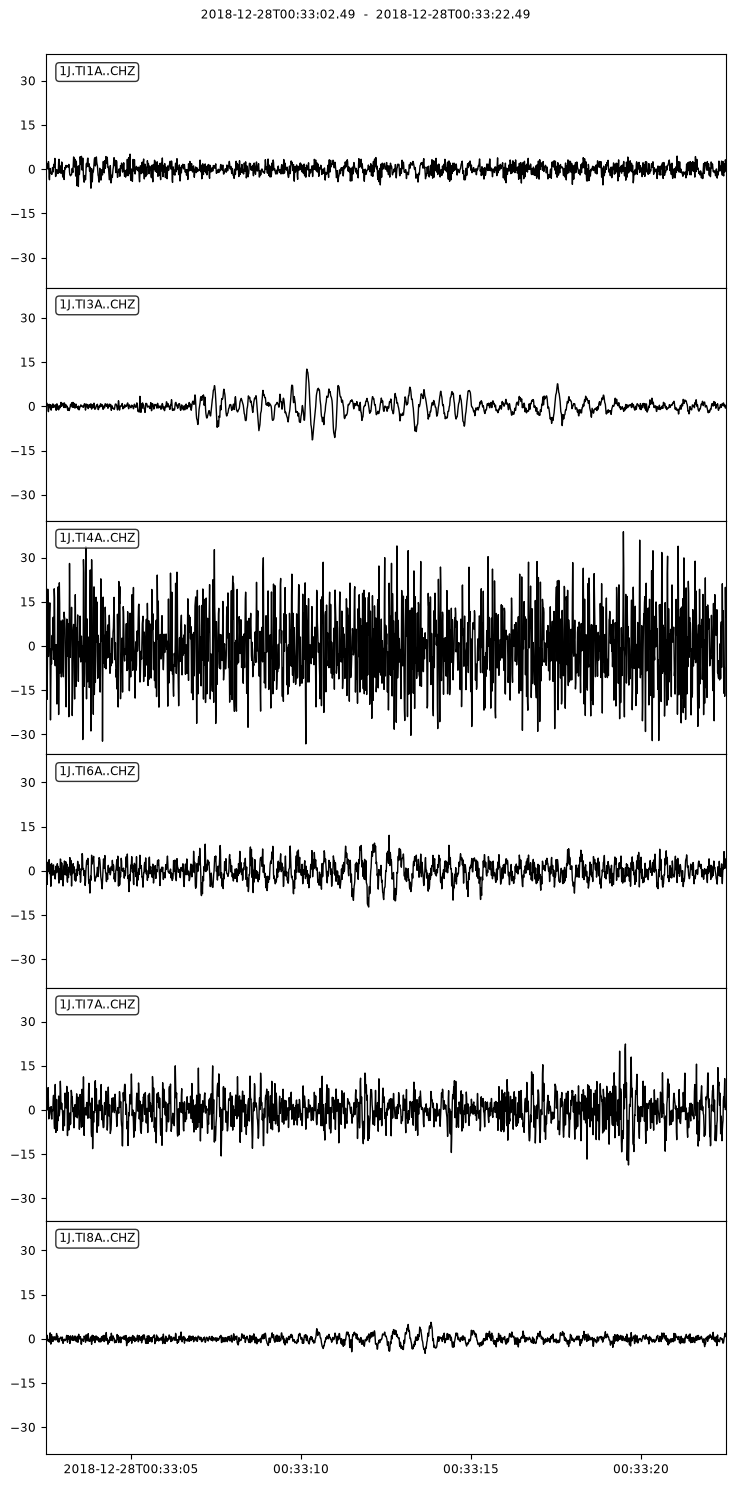

In [22]:
stream = test_event.get_data_window()
stream.plot();

In [67]:
data = np.stack([tr.data for tr in stream],axis=0)
stations = [tr.stats.station for tr in stream]

In [68]:
stations

['TI4A', 'TI3A', 'TI8A', 'TI6A', 'TI1A', 'TI7A']

In [62]:
fmin = 3  # Hz
fmax = 30  # Hz
df = 1./(20)  # sampling step in frequency domain (Hz)
fmin_samples = int(fmin/df)
fmax_samples = int(fmax/df)

In [213]:
stock = st.st(data[3,:],fmin_samples,fmax_samples)

In [214]:
stock.shape

(541, 2001)

In [215]:
freqs = np.linspace(fmin,fmax,stock.shape[0])
times = np.linspace(0,20,stock.shape[1])

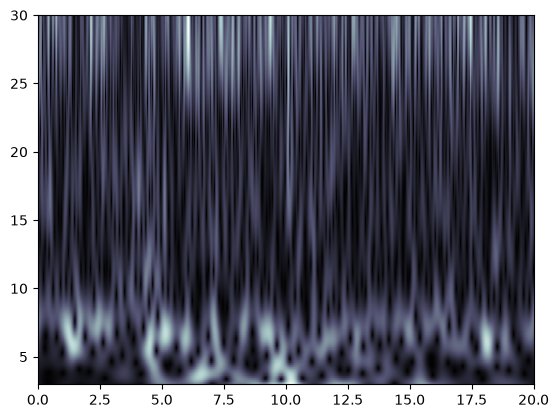

In [216]:
plt.pcolormesh(times,freqs,abs(stock),cmap='bone')

In [217]:
from numpy.fft import rfft, rfftfreq

In [218]:
mod_spec = rfft(abs(stock),axis=1)
freqs2 = rfftfreq(stock.shape[1],d=1/100)

In [219]:
fmin2 = 0.1  # Hz
fmax2 = 1  # Hz

freq_band = freqs2[(freqs2>fmin2) & (freqs2<fmax2)]
mod_spec_band = mod_spec[:,(freqs2>fmin2) & (freqs2<fmax2)]


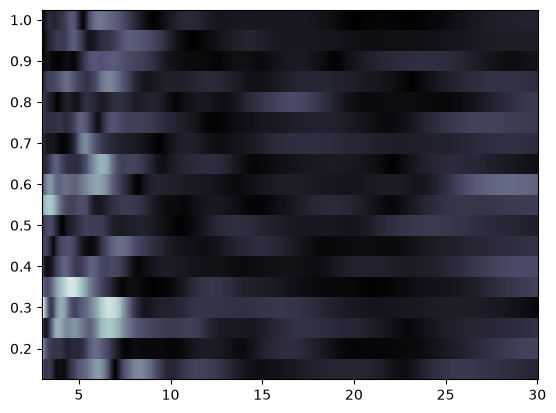

In [220]:
plt.pcolormesh(freqs,freq_band,abs(mod_spec_band).T,cmap='bone')

In [271]:
def make_mod_spec(data,fs,fmin,fmax,fmin2,fmax2):
    window_length = data.shape[1] / fs
    fmin_samples = int(fmin*window_length)
    fmax_samples = int(fmax*window_length)
    stock = np.stack([st.st(data[i,:],fmin_samples,fmax_samples) for i in range(data.shape[0])],axis=0) #shape = (n_stations,n_freqs,n_times)
    freqs = np.linspace(fmin,fmax,stock.shape[1])
    mod_spec = rfft(abs(stock),axis=2) #shape = (n_stations,n_freqs,n_freqs2)
    freqs2 = rfftfreq(stock.shape[2],d=1/fs)

    freq_band = freqs2[(freqs2>fmin2) & (freqs2<fmax2)]
    mod_spec = mod_spec[:,:,(freqs2>fmin2) & (freqs2<fmax2)]
    return freqs,freq_band,mod_spec

In [272]:
freqs, freqs2, mod_spec = make_mod_spec(data,100,3,30,0.1,3)

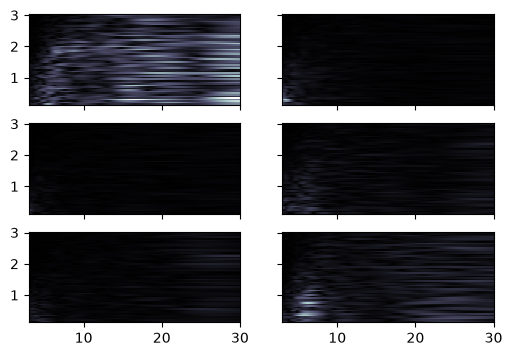

In [274]:
fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(6,4),sharex=True,sharey=True)

for i in range(3):
    for j in range(2):
        ax[i,j].pcolormesh(freqs,freqs2,abs(mod_spec[i*2+j,:,:]).T,cmap='bone',vmin=0,vmax=abs(mod_spec).max())
        #ax[i,j].set_title(f'Station: {stations[i*2+j]}')
        #ax[i,j].set_xlabel('Frequency (Hz)')
        #ax[i,j].set_ylabel('Modulation Frequency (Hz)')

In [170]:
fmin2 = 0.1  # Hz
fmax2 = 1  # Hz
df2 = 1./(20)  # sampling step in frequency domain (Hz)

fmin_samples2 = int(fmin2/df2)
fmax_samples2 = int(fmax2/df2)

rows = []

for i in range(0,stock.shape[0]):
    row = abs(stock)[i,:]
    stock2 = st.st(row,fmin_samples2,fmax_samples2)
    modulation = np.mean(abs(stock2),axis=1)
    rows.append(modulation)

freqs2 = np.linspace(fmin2,fmax2,stock2.shape[0])


In [171]:
spec = np.stack(rows,axis=0)

In [172]:
spec.shape

(541, 19)

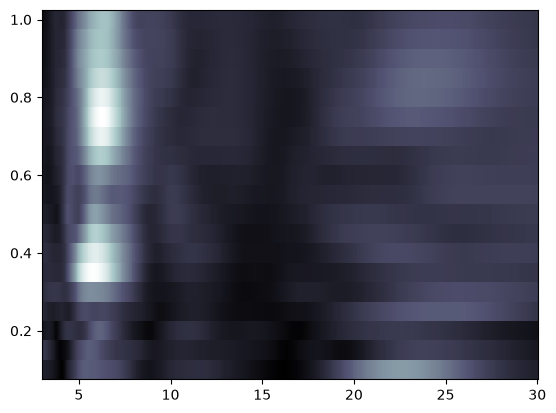

In [173]:
plt.pcolormesh(freqs,freqs2,spec.T,cmap='bone')

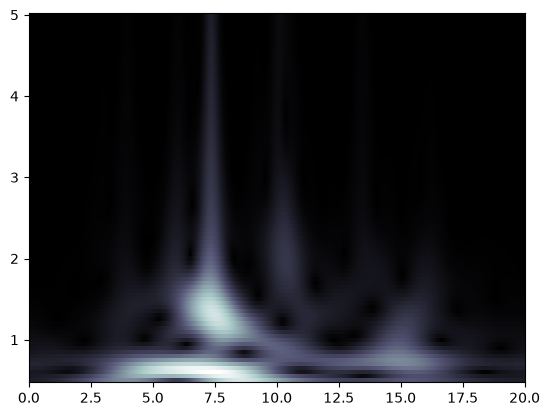

In [109]:
plt.pcolormesh(times,freqs2,abs(stock2),cmap='bone')

In [93]:
from numpy.fft import rfft

In [94]:
modulation = rfft(abs(stock),axis=1)

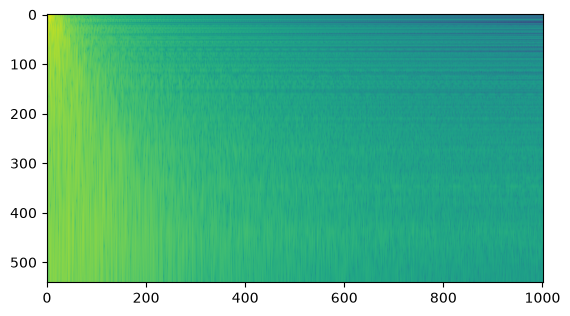

In [95]:
plt.imshow(np.log10(abs(modulation)))

In [87]:
abs(modulation).min()

np.float64(6.830328136142128e-12)